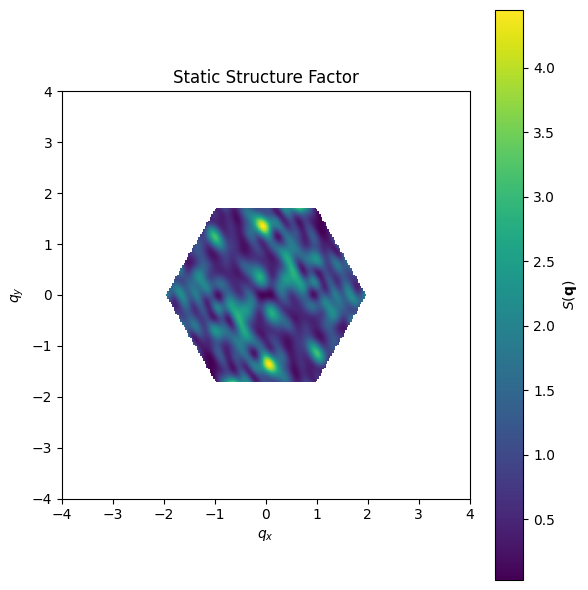

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Load your data here
# -----------------------------
# Example: random spins on honeycomb-like lattice (replace with your data)

filename = "spin_dynamics.txt"   # <-- your file name
select_t = None                  # e.g. 1000 to pick only t=1000
                                 # None = use all rows (average-like)

nq = 250                         # q-grid resolution



data = np.loadtxt(filename, delimiter=None)

t = data[:,0].astype(int)
i = data[:,1].astype(int)
j = data[:,2].astype(int)
S = data[:,3:6]

def generate_test_lattice(Lx=20, Ly=20):
    a1 = np.array([1.0, 0.0])
    a2 = np.array([0.5, np.sqrt(3)/2])

    r = []
    for i in range(Lx):
        for j in range(Ly):
            R = i*a1 + j*a2
            r.append(R)                 # sublattice A
            r.append(R + np.array([0.0, 1/np.sqrt(3)]))  # sublattice B

    r = np.array(r)
    N = len(r)

    # random spins (replace with MC output)
    S = np.random.randn(N,3)
    S /= np.linalg.norm(S,axis=1)[:,None]

    return r, S


# -----------------------------
# Structure factor calculation
# -----------------------------

def compute_structure_factor(r, S, nq=300):
    N = len(r)

    qx = np.linspace(-4, 4, nq)
    qy = np.linspace(-4, 4, nq)
    Sq = np.zeros((nq, nq))

    for ix, qxi in enumerate(qx):
        for iy, qyi in enumerate(qy):
            q = np.array([qxi, qyi])
            phase = np.exp(1j * (r @ q))
            Mq = np.sum(S * phase[:, None], axis=0)
            Sq[iy, ix] = np.real(np.dot(Mq, np.conj(Mq))) / N

    return qx, qy, Sq


# -----------------------------
# Hexagonal Brillouin zone mask
# -----------------------------

def hexagon_mask(qx, qy):
    mask = np.zeros((len(qy), len(qx)), dtype=bool)
    for i, x in enumerate(qx):
        for j, y in enumerate(qy):
            X = abs(x)
            Y = abs(y)
            if (Y < np.sqrt(3)) and (np.sqrt(3)*X + Y < 2*np.sqrt(3)):
                mask[j,i] = True
    return mask


# -----------------------------
# Main
# -----------------------------

r, S = generate_test_lattice()

qx, qy, Sq = compute_structure_factor(r, S, nq=250)

mask = hexagon_mask(qx, qy)
Sq_masked = np.where(mask, Sq, np.nan)

plt.figure(figsize=(6,6))
plt.imshow(Sq_masked, extent=[qx.min(),qx.max(),qy.min(),qy.max()],
           origin='lower', aspect='equal')
plt.colorbar(label=r"$S(\mathbf{q})$")
plt.title("Static Structure Factor")
plt.xlabel(r"$q_x$")
plt.ylabel(r"$q_y$")
plt.tight_layout()
plt.show()


T= 1.0


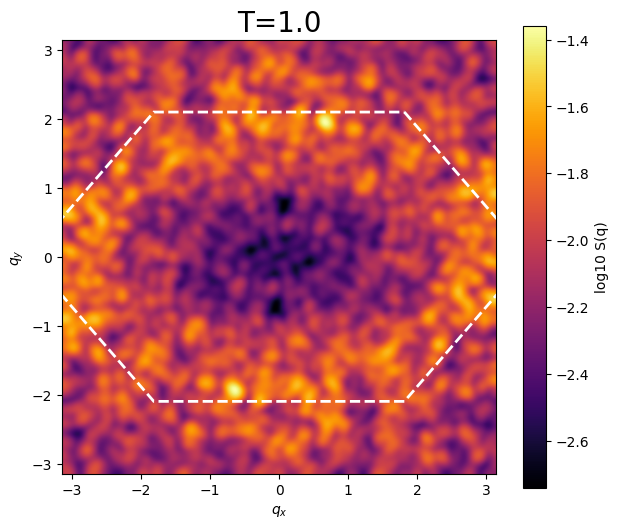

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from matplotlib.patches import Polygon

def get_hexagonal_bz_vertices():
    """Defines the vertices of the 1st Brillouin zone for a honeycomb lattice."""
    # Assuming a lattice constant 'a' that sets the BZ extent
    # These coordinates are standard K and M points in reciprocal space
    K_point = 2 * np.pi / np.sqrt(3) 
    M_point = np.pi * 2/3

    vertices = [
        (K_point/2, M_point),        # Point 1 (M point)
        (K_point, 0),                # Point 2 (K point)
        (K_point/2, -M_point),       # Point 3 (M point)
        (-K_point/2, -M_point),      # Point 4 (M point)
        (-K_point, 0),               # Point 5 (K point)
        (-K_point/2, M_point)        # Point 6 (M point)
    ]
    return vertices

# --------------------------
# Parameters
# --------------------------
Lx=400       # number of lattice sites in x
Ly=400       # number of lattice sites in y
sigma=4.0   # Gaussian smoothing in q-space (pixels)
use_log =True  # True: log scale, False: linear

# ... (rest of your data loading and S(q) calculation code remains the same)
# --------------------------
# Load data
# --------------------------
# Assuming your file has columns: T, i, j, sx, sy, sz
data = np.loadtxt("spin_dynamics")
i = data[:,1].astype(int)
j = data[:,2].astype(int)
sx = data[:,3]
sy = data[:,4]
sz = data[:,5]
T=   data[1,0]

# --------------------------
# Compute S(q)
# --------------------------
# Initialize spin lattice
Sx = np.zeros((Lx,Ly))
Sy = np.zeros((Lx,Ly))
Sz = np.zeros((Lx,Ly))

# Fill lattice
for idx in range(len(i)):
    Sx[i[idx]%Lx, j[idx]%Ly] = sx[idx]
    Sy[i[idx]%Lx, j[idx]%Ly] = sy[idx]
    Sz[i[idx]%Lx, j[idx]%Ly] = sz[idx]

# Compute Fourier transform
Sq_x = np.fft.fft2(Sx)
Sq_y = np.fft.fft2(Sy)
Sq_z = np.fft.fft2(Sz)

# Shift zero frequency to center
Sq_x = np.fft.fftshift(Sq_x)
Sq_y = np.fft.fftshift(Sq_y)
Sq_z = np.fft.fftshift(Sq_z)

# Compute total S(q)
Sq = (np.abs(Sq_x)**2 + np.abs(Sq_y)**2 + np.abs(Sq_z)**2)/ (Lx*Ly)

# Optional smoothing
Sq_smooth = gaussian_filter(Sq, sigma=sigma)

# --------------------------
# Plot
# --------------------------
fig, ax = plt.subplots(figsize=(7, 6))

# Define the extent for the plot (based on standard Pi, not BZ vertices for imshow)
plot_extent = [-np.pi, np.pi, -np.pi, np.pi]

# Decide scale and plot the data
if use_log:
    im = ax.imshow(np.log10(Sq_smooth + 1e-8), origin='lower', cmap='inferno', 
                   extent=plot_extent, aspect='equal')
    cb = fig.colorbar(im, ax=ax)
    cb.set_label('log10 S(q)')
else:
    im = ax.imshow(Sq_smooth, origin='lower', cmap='inferno', 
                   extent=plot_extent, aspect='equal')
    cb = fig.colorbar(im, ax=ax)
    cb.set_label('S(q)')

# Add the hexagonal BZ boundary as an overlay
bz_vertices = get_hexagonal_bz_vertices()
# Create a polygon patch (white, dashed line, no fill)
bz_hexagon = Polygon(bz_vertices, closed=True, fill=False, edgecolor='white', linestyle='--', linewidth=2)
ax.add_patch(bz_hexagon)

# Set labels and title
font1={'family':'serif','color':'blue','size':10}
font2={'family':'serif','color':'darkred','size':10}
ax.set_xlabel('$q_x$')
ax.set_ylabel('$q_y$')
plt.title('T='+str(T),fontsize=20)
plt.xlim(plot_extent[0], plot_extent[1])
plt.ylim(plot_extent[2], plot_extent[3])
plt.savefig('Sq_hex_BZ.png', bbox_inches='tight')
print('T=',T)
plt.show()


Number of spins used: 900


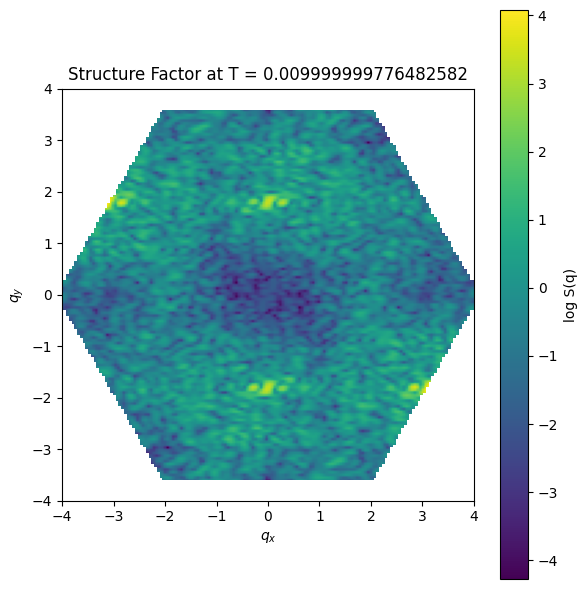

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# ============================
# USER SETTINGS
# ============================
filename = "spin_dynamics.txt"   # <-- change to your filename
T_selected = 0.009999999776482582     # temperature from your file
nq = 150                              # resolution (increase slowly)

# ============================
# LOAD DATA (skip header)
# ============================
data = np.loadtxt(filename, skiprows=1)

t = data[:,0]
i = data[:,1].astype(int)
j = data[:,2].astype(int)
S = data[:,3:6]

# select only chosen temperature
mask = np.isclose(t, T_selected)
i = i[mask]
j = j[mask]
S = S[mask]

print("Number of spins used:", len(S))

# ============================
# BRICK HONEYCOMB GEOMETRY
# ============================
def brick_positions(i, j):
    r = np.zeros((len(i), 2))
    for n, (ii, jj) in enumerate(zip(i, j)):
        # convert to 0-based indexing
        ii -= 1
        jj -= 1

        if ii % 2 == 0:
            x = ii
            y = np.sqrt(3) * jj
        else:
            x = ii + 0.5
            y = np.sqrt(3) * jj + np.sqrt(3)/2

        r[n] = [x, y]

    return r

r = brick_positions(i, j)

# ============================
# STRUCTURE FACTOR
# ============================
def structure_factor(r, S, nq):
    N = len(r)

    qx = np.linspace(-4, 4, nq)
    qy = np.linspace(-4, 4, nq)

    Sq = np.zeros((nq, nq))

    for ix, qxi in enumerate(qx):
        for iy, qyi in enumerate(qy):
            q = np.array([qxi, qyi])
            phase = np.exp(1j * (r @ q))
            Mq = np.sum(S * phase[:,None], axis=0)
            Sq[iy, ix] = (Mq @ np.conj(Mq)).real / N

    return qx, qy, Sq

# ============================
# HEXAGONAL BZ MASK
# ============================
def hexagon_mask(qx, qy):
    mask = np.zeros((len(qy), len(qx)), dtype=bool)
    for ix,x in enumerate(qx):
        for iy,y in enumerate(qy):
            X,Y = abs(x), abs(y)
            if (Y < 2*np.pi/np.sqrt(3)) and (np.sqrt(3)*X + Y < 4*np.pi/np.sqrt(3)):
                mask[iy,ix] = True
    return mask

# ============================
# COMPUTE AND PLOT
# ============================
qx, qy, Sq = structure_factor(r, S, nq)

mask = hexagon_mask(qx, qy)
Sq = np.where(mask, Sq, np.nan)

plt.figure(figsize=(6,6))
plt.imshow(np.log(Sq + 1e-12),
           extent=[qx.min(), qx.max(), qy.min(), qy.max()],
           origin='lower')

plt.xlabel(r"$q_x$")
plt.ylabel(r"$q_y$")
plt.title(f"Structure Factor at T = {T_selected}")
plt.gca().set_aspect("equal")
plt.colorbar(label="log S(q)")
plt.tight_layout()
plt.savefig('sq.png')
plt.show()


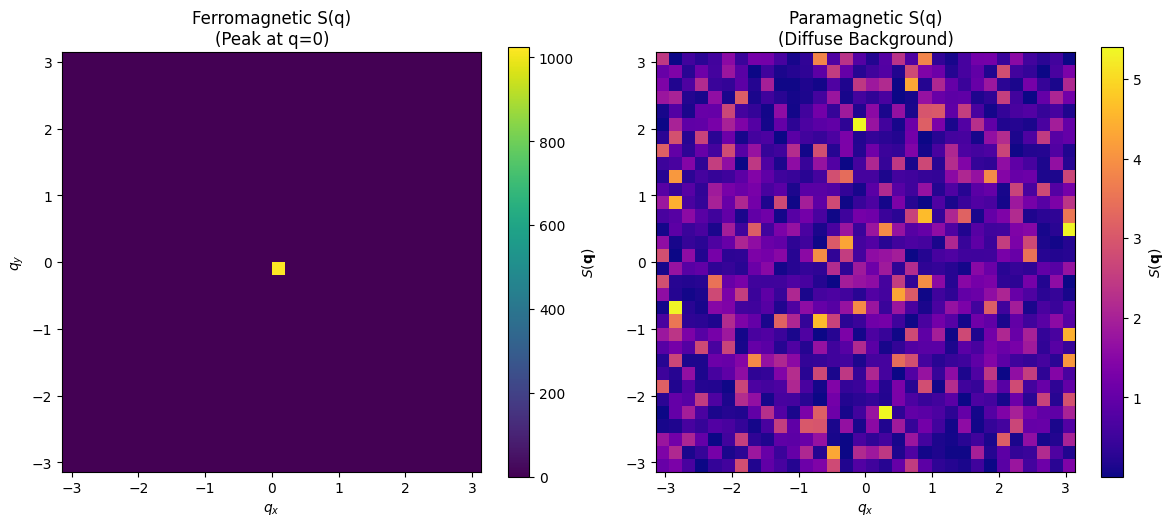

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_structure_factor(spins, L):
    """Computes S(q) using 2D FFT and shifts origin to center."""
    sq_fft = np.fft.fft2(spins)
    sq = (np.abs(sq_fft)**2) / (L * L)
    return np.fft.fftshift(sq)

# 1. Simulation Parameters
L = 32
# Ordered state: High intensity at q=(0,0) [Central Bragg peak]
ferro_state = np.ones((L, L))
# Disordered state: Random noise across all q
para_state = np.random.choice([1, -1], size=(L, L))

# 2. Calculate S(q)
sq_ferro = calculate_structure_factor(ferro_state, L)
sq_para = calculate_structure_factor(para_state, L)

# 3. Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Ferromagnet
im1 = axes[0].imshow(sq_ferro, extent=[-np.pi, np.pi, -np.pi, np.pi], cmap='viridis')
axes[0].set_title("Ferromagnetic S(q)\n(Peak at q=0)")
axes[0].set_xlabel("$q_x$")
axes[0].set_ylabel("$q_y$")
fig.colorbar(im1, ax=axes[0], label="$S(\mathbf{q})$")

# Plot Paramagnet
im2 = axes[1].imshow(sq_para, extent=[-np.pi, np.pi, -np.pi, np.pi], cmap='plasma')
axes[1].set_title("Paramagnetic S(q)\n(Diffuse Background)")
axes[1].set_xlabel("$q_x$")
fig.colorbar(im2, ax=axes[1], label="$S(\mathbf{q})$")

plt.tight_layout()
plt.show()
